In [1]:
from mmspao.utils import *
from mmspao import mmspao
import scanpy as sc

set_random_seed(42)
device = 'cuda'


In [2]:
#Load data and perform necessary preprocessing
rna = sc.read('/home/data1/linjing0806/multiomics/SpatialGlue/data/Dataset7_Mouse_Brain_ATAC/adata_RNA.h5ad')
atac = sc.read('/home/data1/linjing0806/multiomics/SpatialGlue/data/Dataset7_Mouse_Brain_ATAC/adata_peaks_normalized.h5ad')
sc.pp.filter_cells(rna, min_genes=200)

sc.pp.highly_variable_genes(rna, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(rna, target_sum=1e4)

rna =  rna[:, rna.var['highly_variable']]
atac = atac[rna.obs_names].copy()
adata = rna.copy()
rna = getX(rna,modality='rna')

In [3]:
sc.pp.highly_variable_genes(atac, flavor="seurat_v3", n_top_genes=3000)
atac =  atac[:, atac.var['highly_variable']]
atac = getX(atac, modality='atac')

/home/data1/linjing0806/anaconda3/envs/pytorch_gpu/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


In [4]:
model = mmspao([rna,atac],sel_views='all',combination='all',sparse=True,device=device)
model.train(1600)

perform PCA for each modality:   0%|          | 0/2 [00:00<?, ?it/s]

sparse adj for each modality:   0%|          | 0/2 [00:00<?, ?it/s]

Training KAN for modality 1:   0%|          | 0/1600 [00:00<?, ?it/s]

Training KAN for modality 2:   0%|          | 0/1600 [00:00<?, ?it/s]

In [5]:
model.cluster(adata, n_domains=18, end=2.5)

Leiden clustering:   0%|          | 0/240 [00:00<?, ?it/s]

Found resolution: 1.19 for 18 domains


1.1899999999999995

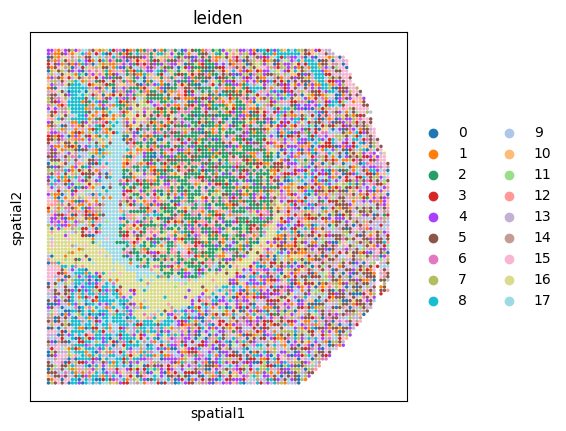

In [6]:
sc.pl.spatial(adata, color="leiden", spot_size=1.0, show=True)

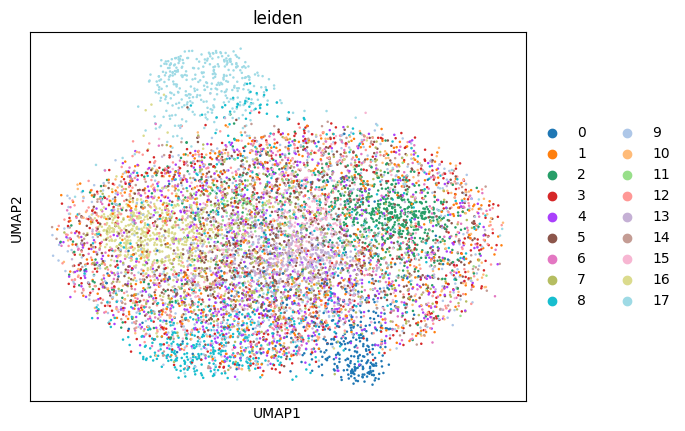

In [7]:
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden",)

In [8]:
{
    'Leiden modularity': model.modularity(adata), # >0.3
    "Moran's I, p_sim": model.moran(adata, k=6), # >0
    "Spatial contiguity ratio": model.contiguity(adata, k=6), # >0.5
}

{'Leiden modularity': 0.2847299726241186,
 "Moran's I, p_sim": (0.18523790625702294, 0.001),
 'Spatial contiguity ratio': 0.15865593736407133}